<a href="https://colab.research.google.com/github/Lmarra1/sympy-workshop-UC3M-2025/blob/main/pendulum_approximations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Math

In [27]:
# --- PENDULUM APPROXIMATION EXPANSIONS ---
# Expand f_continuous (dtheta/dt, domega/dt) in theta using Taylor series around theta = 0

omega_sym = sp.Symbol('omega_sym')
theta_sym = sp.Symbol('theta_sym')  # symbolic placeholder for expansion
f_omega_expr = - (g/L) * sp.sin(theta_sym)



# 1) Linear terms (first-order)
f_omega_lin = f_omega_expr.series(theta_sym, 0, 2).removeO()
print("\nLinear approximation:")
display(f_omega_lin)

# 2) Up to third order
f_omega_3 = f_omega_expr.series(theta_sym, 0, 4).removeO()
print("\nThird order approximation:")
display(f_omega_3)

# 3) Up to fifth order
f_omega_5 = f_omega_expr.series(theta_sym, 0, 6).removeO()
print("\nFifth order approximation:")
display(f_omega_5)

# 4) Up to seventh order
f_omega_7 = f_omega_expr.series(theta_sym, 0, 8).removeO()
print("\Seventh order approximation:")
display(f_omega_7)

# 4) Up to 101 order
f_omega_101 = f_omega_expr.series(theta_sym, 0, 102).removeO()
print("\101 order approximation:")
display(f_omega_101)


# --- Optional: create matrices for continuous-time dynamics ---
# dtheta/dt = omega
f_theta_expr = sp.Symbol('omega_sym')  # placeholder

# Linear, cubic, quartic dynamics as symbolic vectors
f_ful = sp.Matrix([f_theta_expr, f_omega_expr])
f_lin = sp.Matrix([f_theta_expr, f_omega_lin])
f_3rd = sp.Matrix([f_theta_expr, f_omega_3])
f_5th = sp.Matrix([f_theta_expr, f_omega_5])
f_7nd = sp.Matrix([f_theta_expr, f_omega_7])
f_101nd = sp.Matrix([f_theta_expr, f_omega_101])



Linear approximation:


<>:27: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-3044732976.py:27: SyntaxWarning: invalid escape sequence '\S'
  print("\Seventh order approximation:")


-g*theta_sym/L


Third order approximation:


g*theta_sym**3/(6*L) - g*theta_sym/L

...

-g*theta_sym**5/(120*L) + g*theta_sym**3/(6*L) - g*theta_sym/L

\Seventh order approximation:


g*theta_sym**7/(5040*L) - g*theta_sym**5/(120*L) + g*theta_sym**3/(6*L) - g*theta_sym/L

A order approximation:


-g*theta_sym**101/(9425947759838359420851623124482936749562312794702543768327889353416977599316221476503087861591808346911623490003549599583369706302603264000000000000000000000000*L) + g*theta_sym**99/(933262154439441526816992388562667004907159682643816214685929638952175999932299156089414639761565182862536979208272237582511852109168640000000000000000000000*L) - g*theta_sym**97/(96192759682482119853328425949563698712343813919172976158104477319333745612481875498805879175589072651261284189679678167647067832320000000000000000000000*L) + g*theta_sym**95/(10329978488239059262599702099394727095397746340117372869212250571234293987594703124871765375385424468563282236864226607350415360000000000000000000000*L) - g*theta_sym**93/(1156772507081641574759205162306240436214753229576413535186142281213246807121467315215203289516844845303838996289387078090752000000000000000000000*L) + g*theta_sym**91/(13520015276784029625516656875949514214758686647690667779174173459715367077155999476568528395475044942775

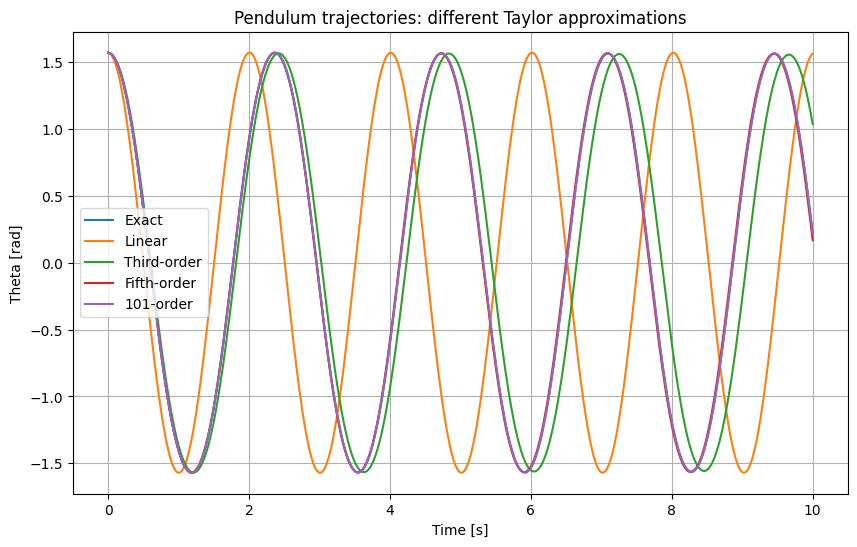

In [28]:
# --- NUMERICAL INTEGRATION AND TRAJECTORY PLOTS ---

# Parameters
g_val = 9.81
L_val = 1.0

# Initial conditions: large initial angle
theta0_val = np.pi / 2  # 90 degrees
omega0_val = 0.0
y0 = [theta0_val, omega0_val]

# Time span
t_span = (0, 10)  # 10 seconds
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# --- Lambdify functions for numerical integration ---
f_ful_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_ful, 'numpy')
f_lin_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_lin, 'numpy')
f_3rd_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_3rd, 'numpy')
f_5th_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_5th, 'numpy')
f_7th_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_7nd, 'numpy')
f_101th_func  = sp.lambdify([theta_sym, omega_sym, g, L], f_101nd, 'numpy')

# --- ODE wrappers ---
def dyn_ful(t, y):  return f_ful_func(y[0], y[1], g_val, L_val).flatten()
def dyn_lin(t, y):  return f_lin_func(y[0], y[1], g_val, L_val).flatten()
def dyn_3rd(t, y):  return f_3rd_func(y[0], y[1], g_val, L_val).flatten()
def dyn_5th(t, y):  return f_5th_func(y[0], y[1], g_val, L_val).flatten()
def dyn_7th(t, y):  return f_7th_func(y[0], y[1], g_val, L_val).flatten()
def dyn_101th(t, y):  return f_101th_func(y[0], y[1], g_val, L_val).flatten()


# --- Solve ODEs ---
sol_ful  = solve_ivp(dyn_ful, t_span, y0, t_eval=t_eval)
sol_lin  = solve_ivp(dyn_lin, t_span, y0, t_eval=t_eval)
sol_3rd  = solve_ivp(dyn_3rd, t_span, y0, t_eval=t_eval)
sol_5th  = solve_ivp(dyn_5th, t_span, y0, t_eval=t_eval)
sol_7th  = solve_ivp(dyn_7th, t_span, y0, t_eval=t_eval)
sol_101th  = solve_ivp(dyn_101th, t_span, y0, t_eval=t_eval)

# --- Plot results ---
plt.figure(figsize=(10,6))
plt.plot(sol_lin.t, sol_ful.y[0], label='Exact')
plt.plot(sol_lin.t, sol_lin.y[0], label='Linear')
plt.plot(sol_3rd.t, sol_3rd.y[0], label='Third-order')
plt.plot(sol_5th.t, sol_5th.y[0], label='Fifth-order')
#plt.plot(sol_7th.t, sol_7th.y[0], label='Seventh-order')
plt.plot(sol_101th.t, sol_101th.y[0], label='101-order')
plt.xlabel('Time [s]')
plt.ylabel('Theta [rad]')
plt.title('Pendulum trajectories: different Taylor approximations')
plt.legend()
plt.grid(True)
plt.show()

# --- OPTIONAL: Compare with exact nonlinear dynamics ---
def dyn_exact(t, y):
    theta, omega = y
    return [omega, - (g_val/L_val) * np.sin(theta)]

sol_exact = solve_ivp(dyn_exact, t_span, y0, t_eval=t_eval)
